# CTR Impact Features

By Yusuf

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('C:/Tempa_dicoding/projek_akhir/Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/data/raw/abis_cleaning.csv')

## 1. Impression to View Rate
impression_to_view_rate = views / impressions

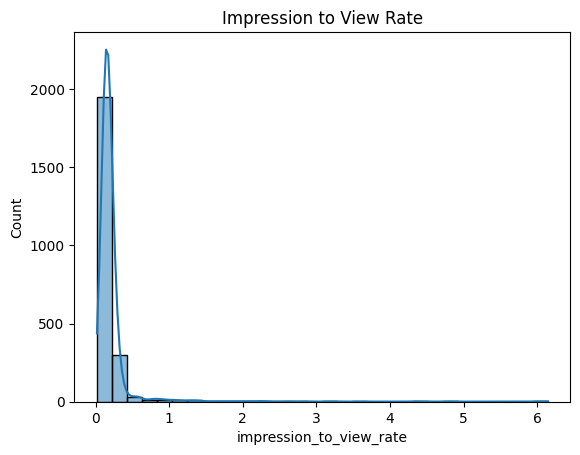

In [7]:
df['impression_to_view_rate'] = df['views'] / (df['impressions'] + 1)
sns.histplot(df['impression_to_view_rate'], bins=30, kde=True)
plt.title('Impression to View Rate')
plt.show()

## 2. CTR Normalized
ctr_normalized = ctr / 100

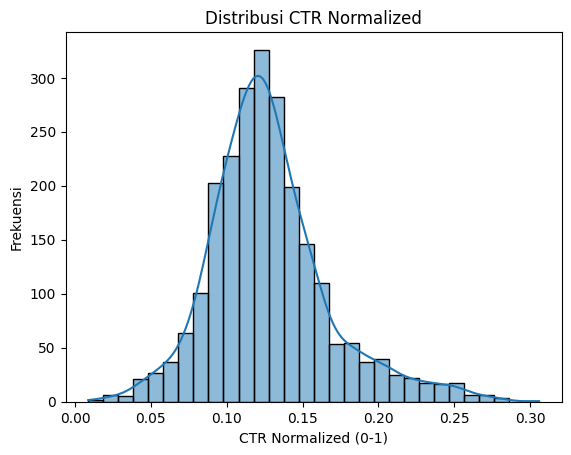

count    2345.000000
mean        0.127755
std         0.039692
min         0.008700
25%         0.103500
50%         0.123100
75%         0.145800
max         0.305900
Name: ctr_normalized, dtype: float64


In [13]:
## 2. CTR Normalized
df['ctr_normalized'] = df['impressions_click_through_rate_pct'] / 100

sns.histplot(df['ctr_normalized'], bins=30, kde=True)
plt.title('Distribusi CTR Normalized')
plt.xlabel('CTR Normalized (0-1)')
plt.ylabel('Frekuensi')
plt.show()

print(df['ctr_normalized'].describe())

## 3. CTR Impression Score
ctr_impression_score = ctr_normalized * impression_to_view_rate

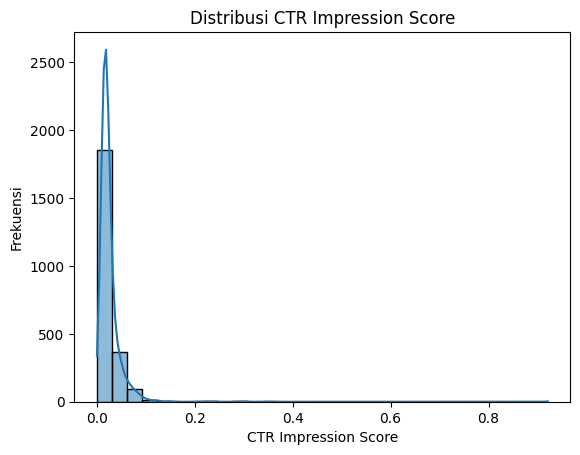

count    2345.000000
mean        0.025517
std         0.028214
min         0.000208
25%         0.014365
50%         0.019469
75%         0.028027
max         0.921237
Name: ctr_impression_score, dtype: float64


In [14]:
## 3. CTR Impression Score
df['ctr_impression_score'] = (
    df['ctr_normalized'] * df['impression_to_view_rate']
)

sns.histplot(df['ctr_impression_score'], bins=30, kde=True)
plt.title('Distribusi CTR Impression Score')
plt.xlabel('CTR Impression Score')
plt.ylabel('Frekuensi')
plt.show()

print(df['ctr_impression_score'].describe())

## 4. CTR Category
ctr_category = bin ctr into Low(<3%), Mid(3-7%), High(>7%)

In [16]:
df['ctr_category'] = pd.cut(
    df['impressions_click_through_rate_pct'],
    bins=[0, 3, 7, float('inf')],
    labels=['Low', 'Mid', 'High'],
    include_lowest=True
)

print(df['ctr_category'].value_counts())

ctr_category
High    2237
Mid      100
Low        8
Name: count, dtype: int64


### CTR Category Analysis

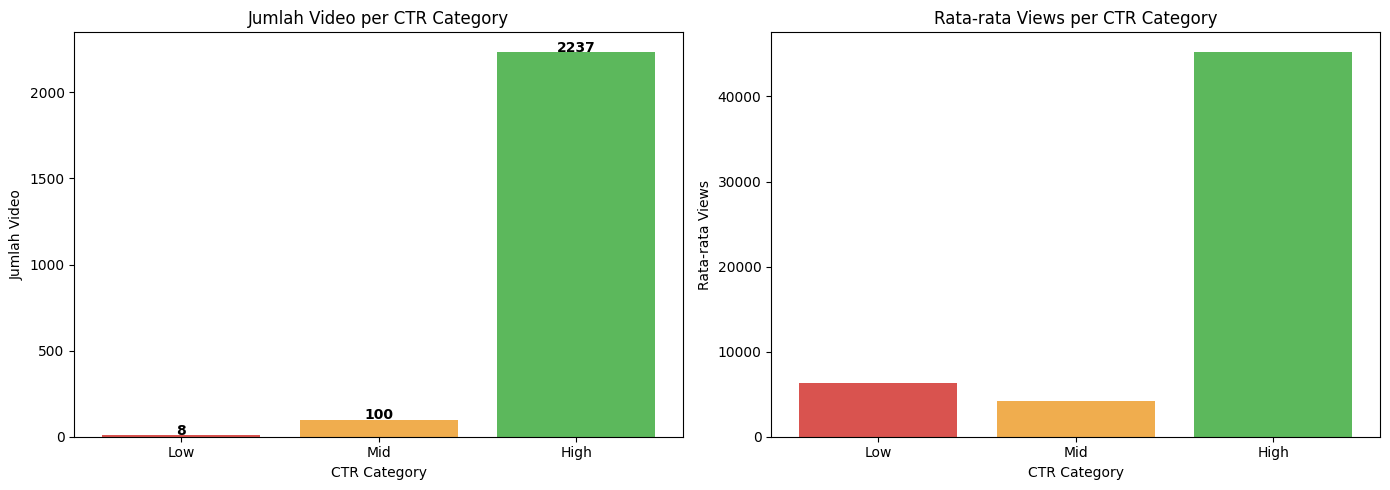


Statistik Views per CTR Category:
               count      mean       std   min      25%      50%      75%  \
ctr_category                                                                
Low              8.0   6345.88   6189.11  37.0  2436.25   5578.5   8171.0   
Mid            100.0   4248.28   4815.45  41.0   854.50   2500.0   5978.0   
High          2237.0  45274.44  97642.66  19.0  5799.00  14363.0  41024.0   

                    max  
ctr_category             
Low             19260.0  
Mid             27412.0  
High          1515626.0  


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ctr_counts = df['ctr_category'].value_counts().reindex(['Low', 'Mid', 'High'])
axes[0].bar(ctr_counts.index, ctr_counts.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[0].set_title('Jumlah Video per CTR Category')
axes[0].set_xlabel('CTR Category')
axes[0].set_ylabel('Jumlah Video')
for i, v in enumerate(ctr_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

avg_views = df.groupby('ctr_category', observed=True)['views'].mean().reindex(['Low', 'Mid', 'High'])
axes[1].bar(avg_views.index, avg_views.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[1].set_title('Rata-rata Views per CTR Category')
axes[1].set_xlabel('CTR Category')
axes[1].set_ylabel('Rata-rata Views')

plt.tight_layout()
plt.show()

print("\nStatistik Views per CTR Category:")
print(df.groupby('ctr_category', observed=True)['views'].describe().round(2))

In [18]:
fitur_baru = ['impression_to_view_rate', 'ctr_normalized', 'ctr_impression_score', 'ctr_category']
print("Kolom setelah feature engineering:")
print(df.columns.tolist())
print(f"\nTotal kolom: {df.shape[1]}")
print(f"Total baris: {df.shape[0]}")
print("\nSample 5 baris fitur baru:")
df[fitur_baru].head()

Kolom setelah feature engineering:
['video_id', 'video_title', 'waktu_publikasi_video', 'duration', 'engaged_views', 'estimated_adsense_revenue_idr', 'subscriber_yang_diperoleh', 'subscriber_yang_hilang', 'suka', 'tidak_suka', 'komentar_ditambahkan', 'average_percentage_viewed_pct', 'youtube_premium_idr', 'watch_page_ads_idr', 'youtube_ad_revenue_idr', 'ad_impressions', 'playback_based_cpm_idr', 'cpm_idr', 'estimated_monetized_playbacks', 'rpm_idr', 'youtube_premium_watch_time_hours', 'youtube_premium_views', 'end_screen_elements_shown', 'end_screen_element_clicks', 'views', 'watch_time_hours', 'subscribers', 'estimated_revenue_idr', 'impressions', 'impressions_click_through_rate_pct', 'judul', 'tanggal_upload', 'ts1_views', 'ts2_views', 'ts3_views', 'ts4_views', 'upload_time_wib', 'average_view_duration_sec', 'is_viral', 'watch_time_hours_log', 'engaged_views_log', 'views_log', 'impression_to_view_rate', 'ctr_normalized', 'ctr_impression_score', 'ctr_category']

Total kolom: 46
Total 

,impression_to_view_rate,ctr_normalized,ctr_impression_score,ctr_category
0,0.135947,0.1189,0.016164,High
1,0.120665,0.1064,0.012839,High
2,0.131765,0.1072,0.014125,High
3,0.157811,0.1308,0.020642,High
4,0.132473,0.1156,0.015314,High


## Save Data

In [ ]:
import os


output_dir = '../data/processed/'
output_path = os.path.join(output_dir, 'features_ctr.csv')

os.makedirs(output_dir, exist_ok=True)
df.to_csv(output_path, index=False)

print(f"Data saved successfully: {output_path} | Shape: {df.shape}")

Data saved successfully: ../data/processed/features_ctr.csv | Shape: (2345, 46)
